# Deep RNN Model
## IMDb dataset

In [5]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.0 MB/s eta 0:00:00


In [26]:
!pip install keras-tuner --quiet

Import Library

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import Hyperband
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import numpy as np
import keras_tuner as kt

Load Dataset

In [30]:
# Load IMDb dataset
num_words = 10000
max_len = 250

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)


Model RNN & Hyperparameter Tuning Function

In [31]:
def build_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=num_words,
                        output_dim=hp.Choice('embedding_dim', [64, 128]),
                        input_length=max_len))

    # Deep RNN - lebih dari 1 lapisan RNN
    model.add(SimpleRNN(units=hp.Int('rnn_units1', 64, 256, step=64),
                        return_sequences=True))
    model.add(Dropout(rate=hp.Float('dropout1', 0.2, 0.5, step=0.1)))

    model.add(SimpleRNN(units=hp.Int('rnn_units2', 32, 128, step=32)))
    model.add(Dropout(rate=hp.Float('dropout2', 0.2, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model


Cari Hyperparameter Terbaik

In [34]:
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=5,
                     directory='tuner_rnn',
                     project_name='deep_rnn_imdb')

tuner.search(x_train, y_train, epochs=5, validation_split=0.2, verbose=1)
best_hps = tuner.get_best_hyperparameters(1)[0]


Trial 10 Complete [00h 03m 16s]
val_accuracy: 0.5099999904632568

Best val_accuracy So Far: 0.868399977684021
Total elapsed time: 00h 18m 53s


Training dengan Hyperparameter Terbaik

In [35]:
model = tuner.hypermodel.build(best_hps)

history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.5209 - loss: 0.7195 - val_accuracy: 0.7564 - val_loss: 0.5045
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8069 - loss: 0.4414 - val_accuracy: 0.8387 - val_loss: 0.3825
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.8881 - loss: 0.2920 - val_accuracy: 0.8655 - val_loss: 0.3198
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.9232 - loss: 0.2172 - val_accuracy: 0.8521 - val_loss: 0.3532
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9404 - loss: 0.1756 - val_accuracy: 0.8613 - val_loss: 0.3422
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9523 - loss: 0.1401 - val_accuracy: 0.8598 - val_loss: 0.4136
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.9660 - loss: 0.1080 - val_accuracy: 0.8501 - val_loss: 0.4369
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9769 - loss: 0.0751 - 

Evaluasi

In [38]:
# Prediksi Probabilitas & Kelas
y_pred_probs = model.predict(x_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

# Evaluasi
print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_probs))
print("F1 Score:", f1_score(y_test, y_pred))
print("Presisi:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     12500
           1       0.88      0.82      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000

AUC Score: 0.9195362368
F1 Score: 0.8489404766822256
Presisi: 0.877615509437185
Recall: 0.82208


In [37]:
# Akurasi pada Training dan Testing dalam bentuk persen
train_accuracy = history.history['accuracy'][-1] * 100
test_accuracy = history.history['val_accuracy'][-1] * 100

print(f"Akurasi pada Training Set: {train_accuracy:.2f}%")
print(f"Akurasi pada Testing Set: {test_accuracy:.2f}%")

Akurasi pada Training Set: 98.84%
Akurasi pada Testing Set: 85.37%


Visualisasi AUC ROC

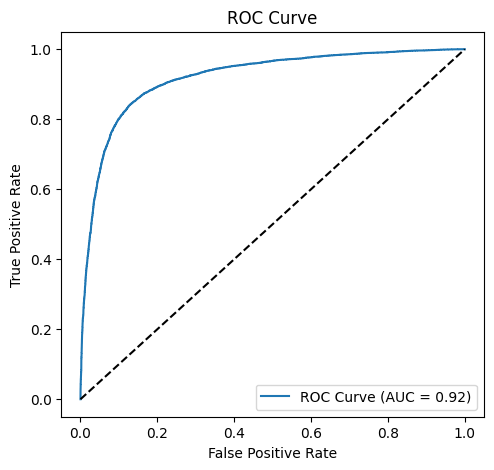

In [42]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(y_test, y_pred_probs)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()


Visualisasi Akurasi dan Loss

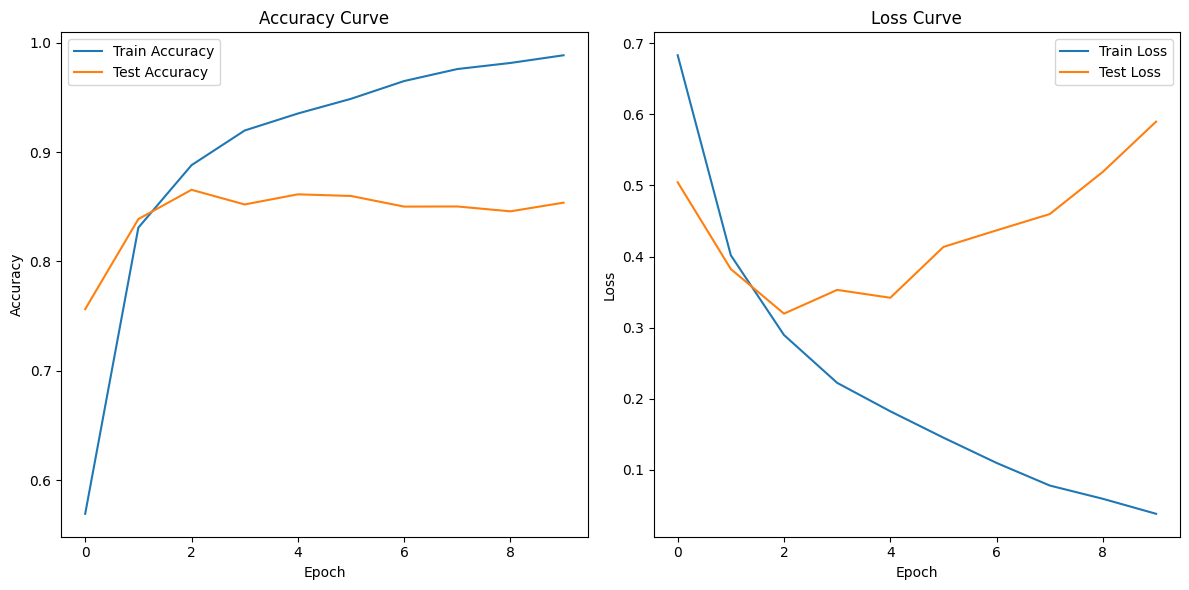

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()
